In [1]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from  vip_slap2_analysis.behavior import preprocess as ps
from vip_slap2_analysis.utils.utils import normalize_timeseries as normalize

sns.set()
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%xmode Plain

Exception reporting mode: Plain


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
%matplotlib notebook

In [5]:
basepath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics"

In [6]:
summary_path = glob.glob(os.path.join(basepath,'**summary.xlsx'))[0]
summary_df = pd.read_excel(summary_path,sheet_name='subjects')
session_df = pd.read_excel(summary_path,sheet_name='sessions')

In [7]:
target_mice = [826033]

In [8]:
process_df = session_df[(session_df['subject_id'].isin(target_mice))&(session_df['session_type']!='expression_check')]

In [9]:
process_df

,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_name,instrument_id,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
75,826033_2026-02-17_13-13-55,826033,2,2026-02-17,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,slap2_albert,SLAP2_1,yes,no,VCO.1,good,stimlus ID not recorded properly,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
76,826033_2026-02-18_11-57-04,826033,3,2026-02-18,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,slap2_albert,SLAP2_1,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
77,826033_2026-02-19_13-47-57,826033,4,2026-02-19,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,slap2_albert,SLAP2_1,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
78,826033_2026-02-21_09-23-34,826033,5,2026-02-21,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,slap2_albert,SLAP2_1,yes,no,VCO.1,good,MoCo failed in last 3min of experiment,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
79,826033_2026-02-23_10-45-21,826033,6,2026-02-23,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,slap2_albert,SLAP2_1,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


### Process DoC session collected w/ HARP/Bonsai

In [10]:
for idx,row in process_df.iterrows():
    try:
        harp_path = glob.glob(os.path.join(row['session_dir'],'**','**Behavior.harp'),recursive=True)[0]
        print(harp_path)
        if 'device.yml' in os.listdir(harp_path):
            print('metadata present')
        else:
            print('no metadata')
        if 'extracted_files' in os.listdir(harp_path):
            print('processed')
            pass
        else:
            print('processing...')
            try:
                ps.process_single_harp_session(harp_path)
            except:
                print('error processing')
        print('\n')
    except:
        
        print(f'No path for {row["session"]}','\n')

\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-17_13-13-55\behavior\VCO1_Behavior.harp
metadata present
processed


\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-18_11-57-04\behavior\VCO1_Behavior.harp
metadata present
processed


\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-19_13-47-57\behavior\VCO1_Behavior.harp
metadata present
processed


\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-21_09-23-34\behavior\VCO1_Behavior.harp
metadata present
processed


\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-23_10-45-21\behavior\VCO1_Behavior.harp
metadata present
processing...
Processing \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-23_10-45-21\behavior\VCO1_Behavior.harp...
→ Saved data to \\allen

### QC behavior data


=== 826033_2026-02-17_13-13-55 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-17_13-13-55\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-17_13-13-55\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 1
[BAD] Stimulus IDs not correctly recorded

=== 826033_2026-02-18_11-57-04 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-18_11-57-04\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-18_11-57-04\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 7
826033_2026-02-18_11-57-04 timestamps already corrected


<IPython.core.display.Javascript object>


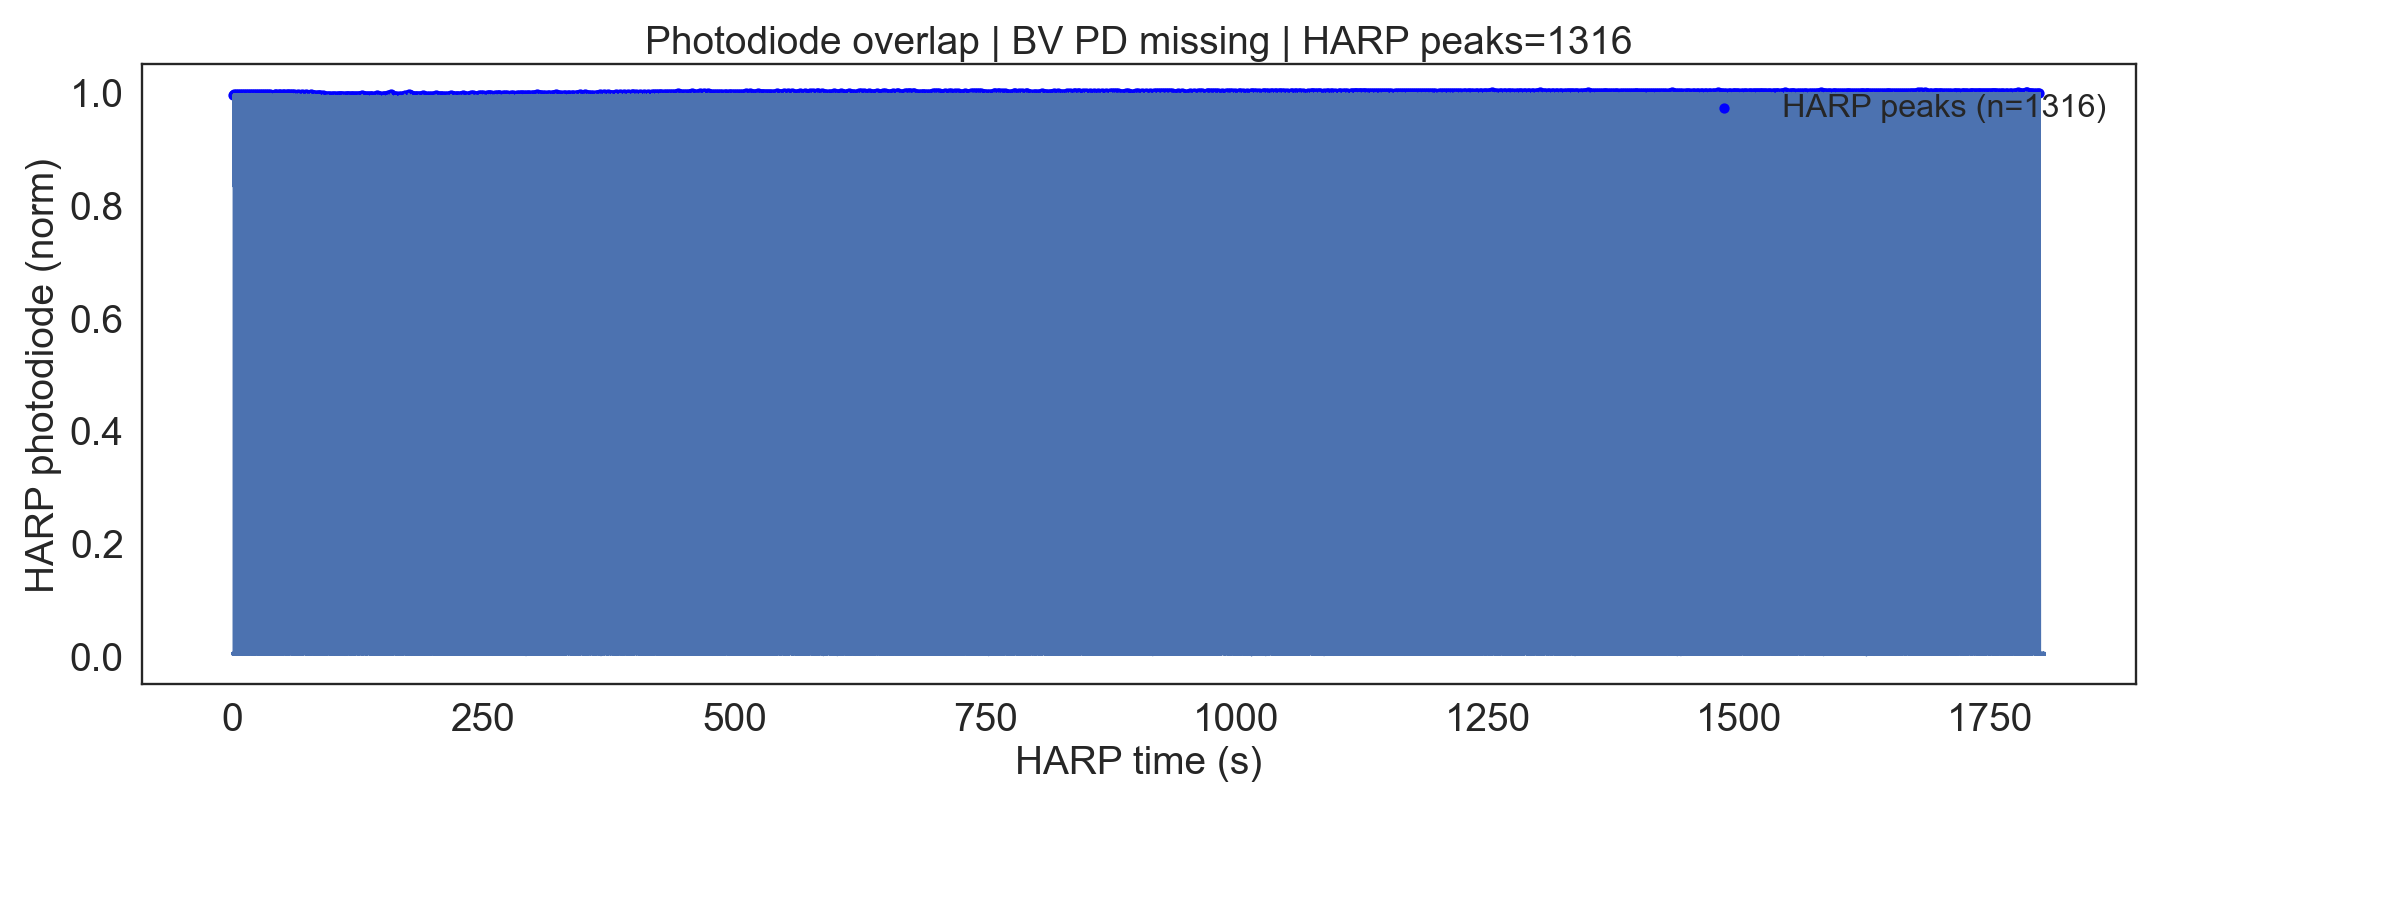


=== 826033_2026-02-19_13-47-57 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-19_13-47-57\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-19_13-47-57\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 7
826033_2026-02-19_13-47-57 timestamps already corrected


<IPython.core.display.Javascript object>


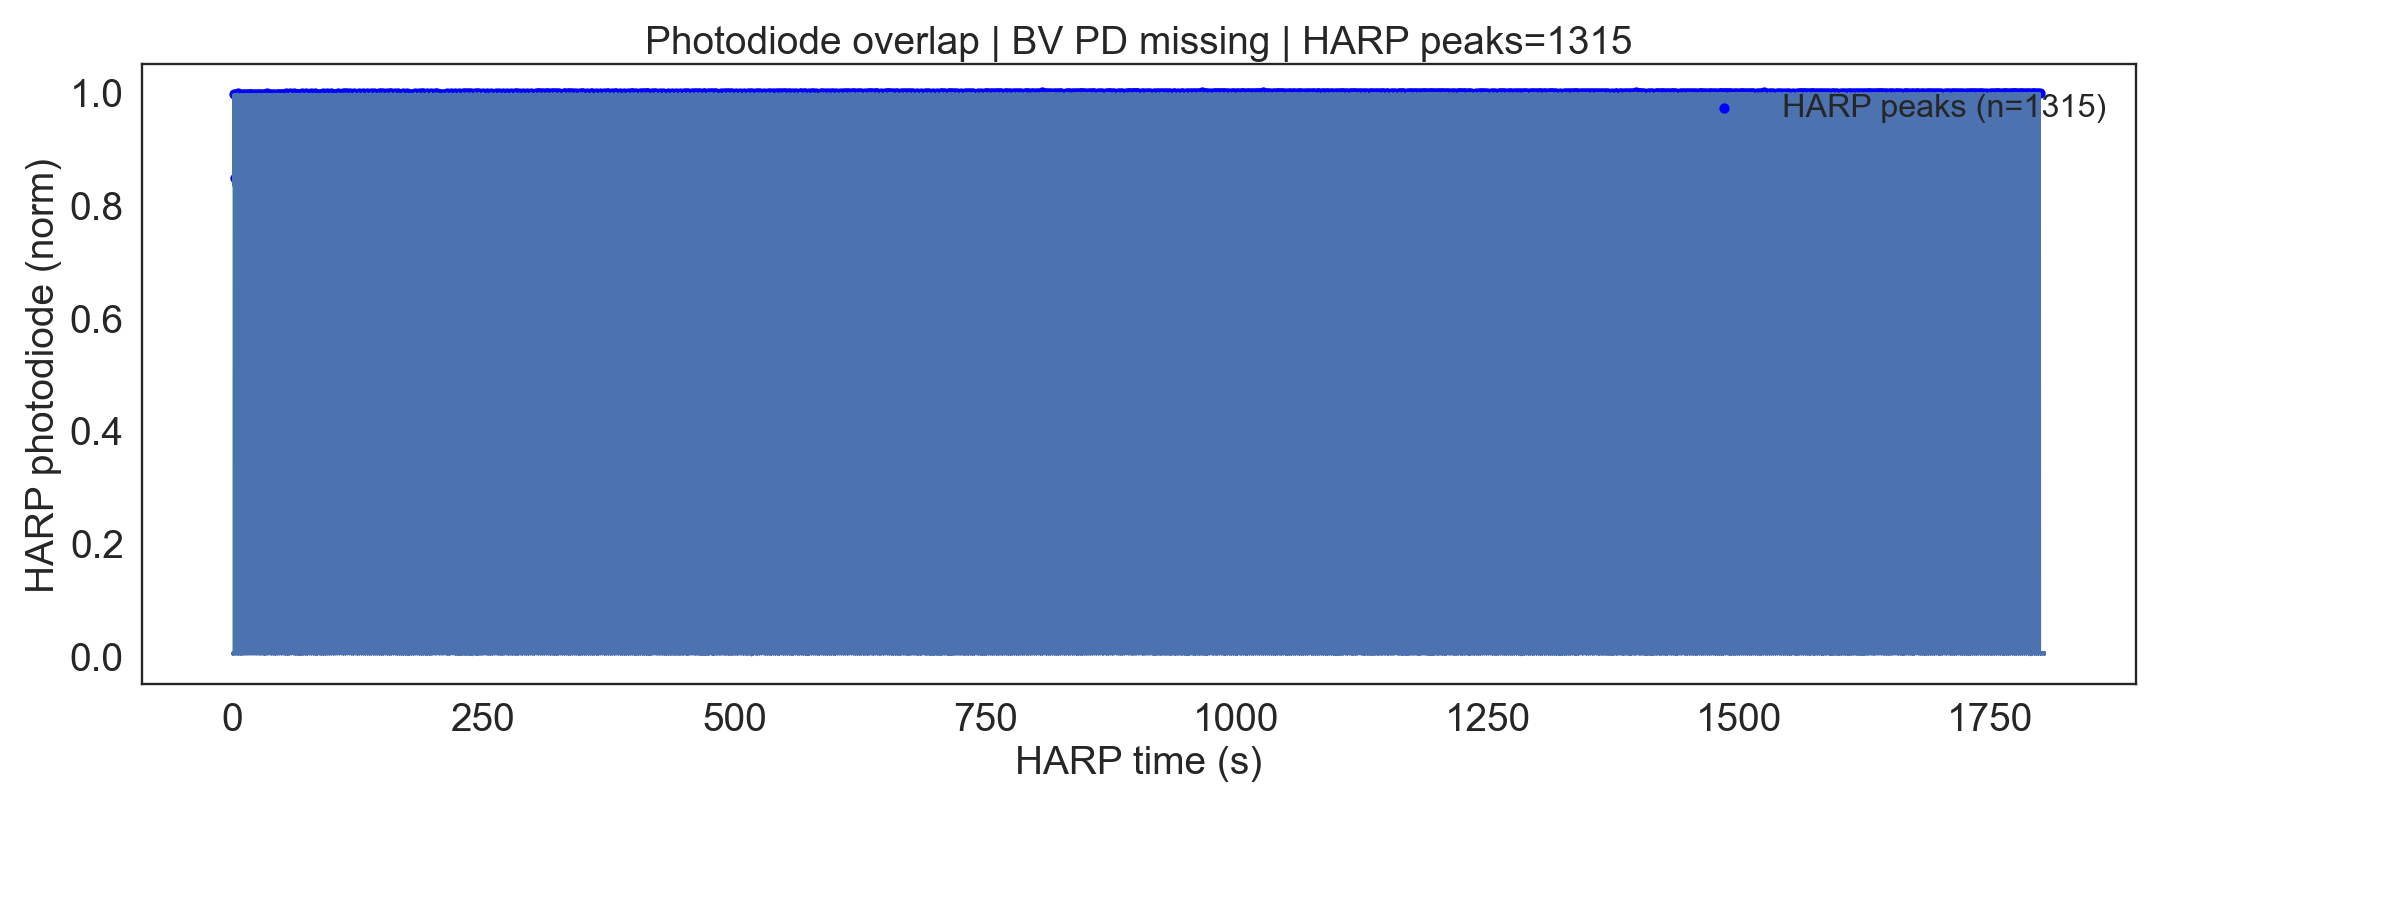


=== 826033_2026-02-21_09-23-34 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-21_09-23-34\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-21_09-23-34\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 7
826033_2026-02-21_09-23-34 timestamps already corrected


<IPython.core.display.Javascript object>


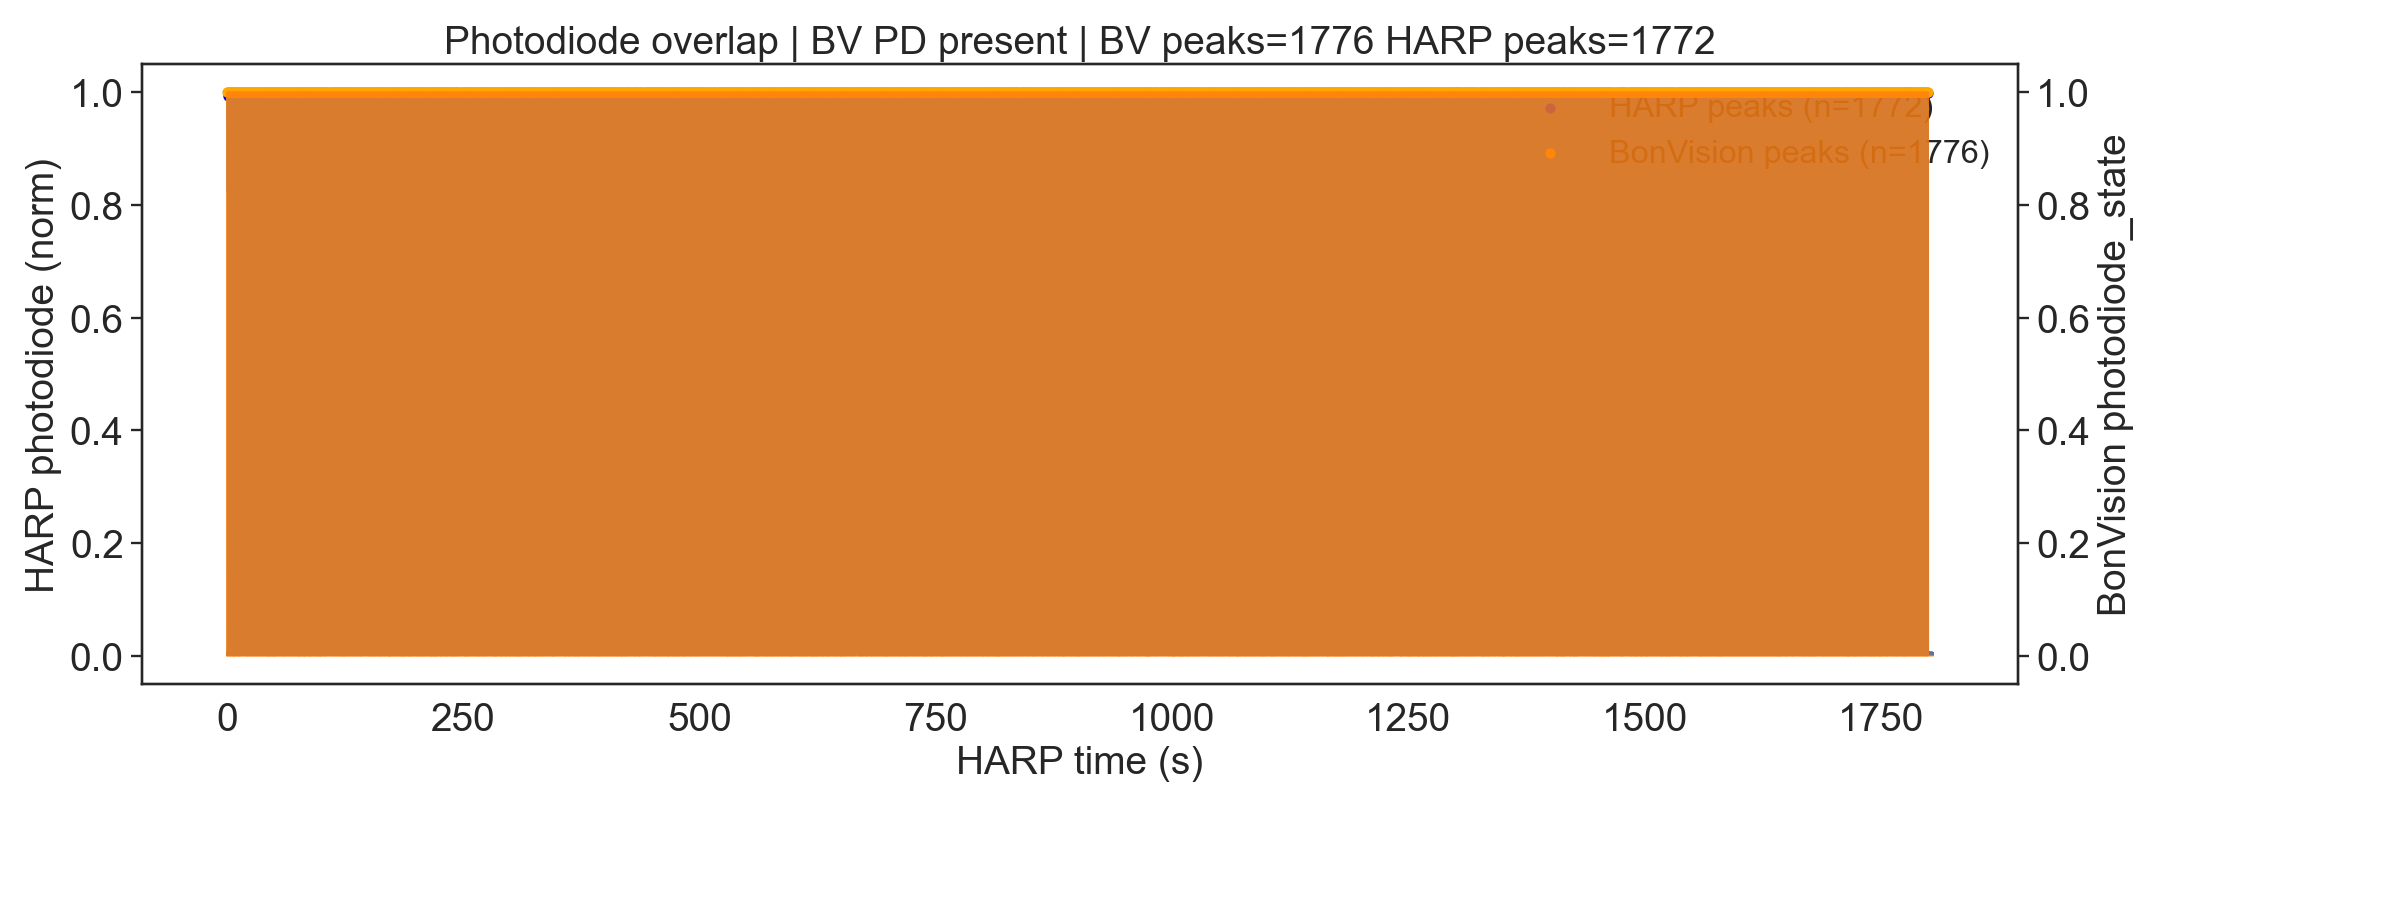


=== 826033_2026-02-23_10-45-21 ===
event_log: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-23_10-45-21\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
photodiode: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-23_10-45-21\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl
unique stim IDs (tif/tiff): 7
[OK] corrected via bv_photodiode_piecewise | slope=1.000007 b=0.201s


<IPython.core.display.Javascript object>


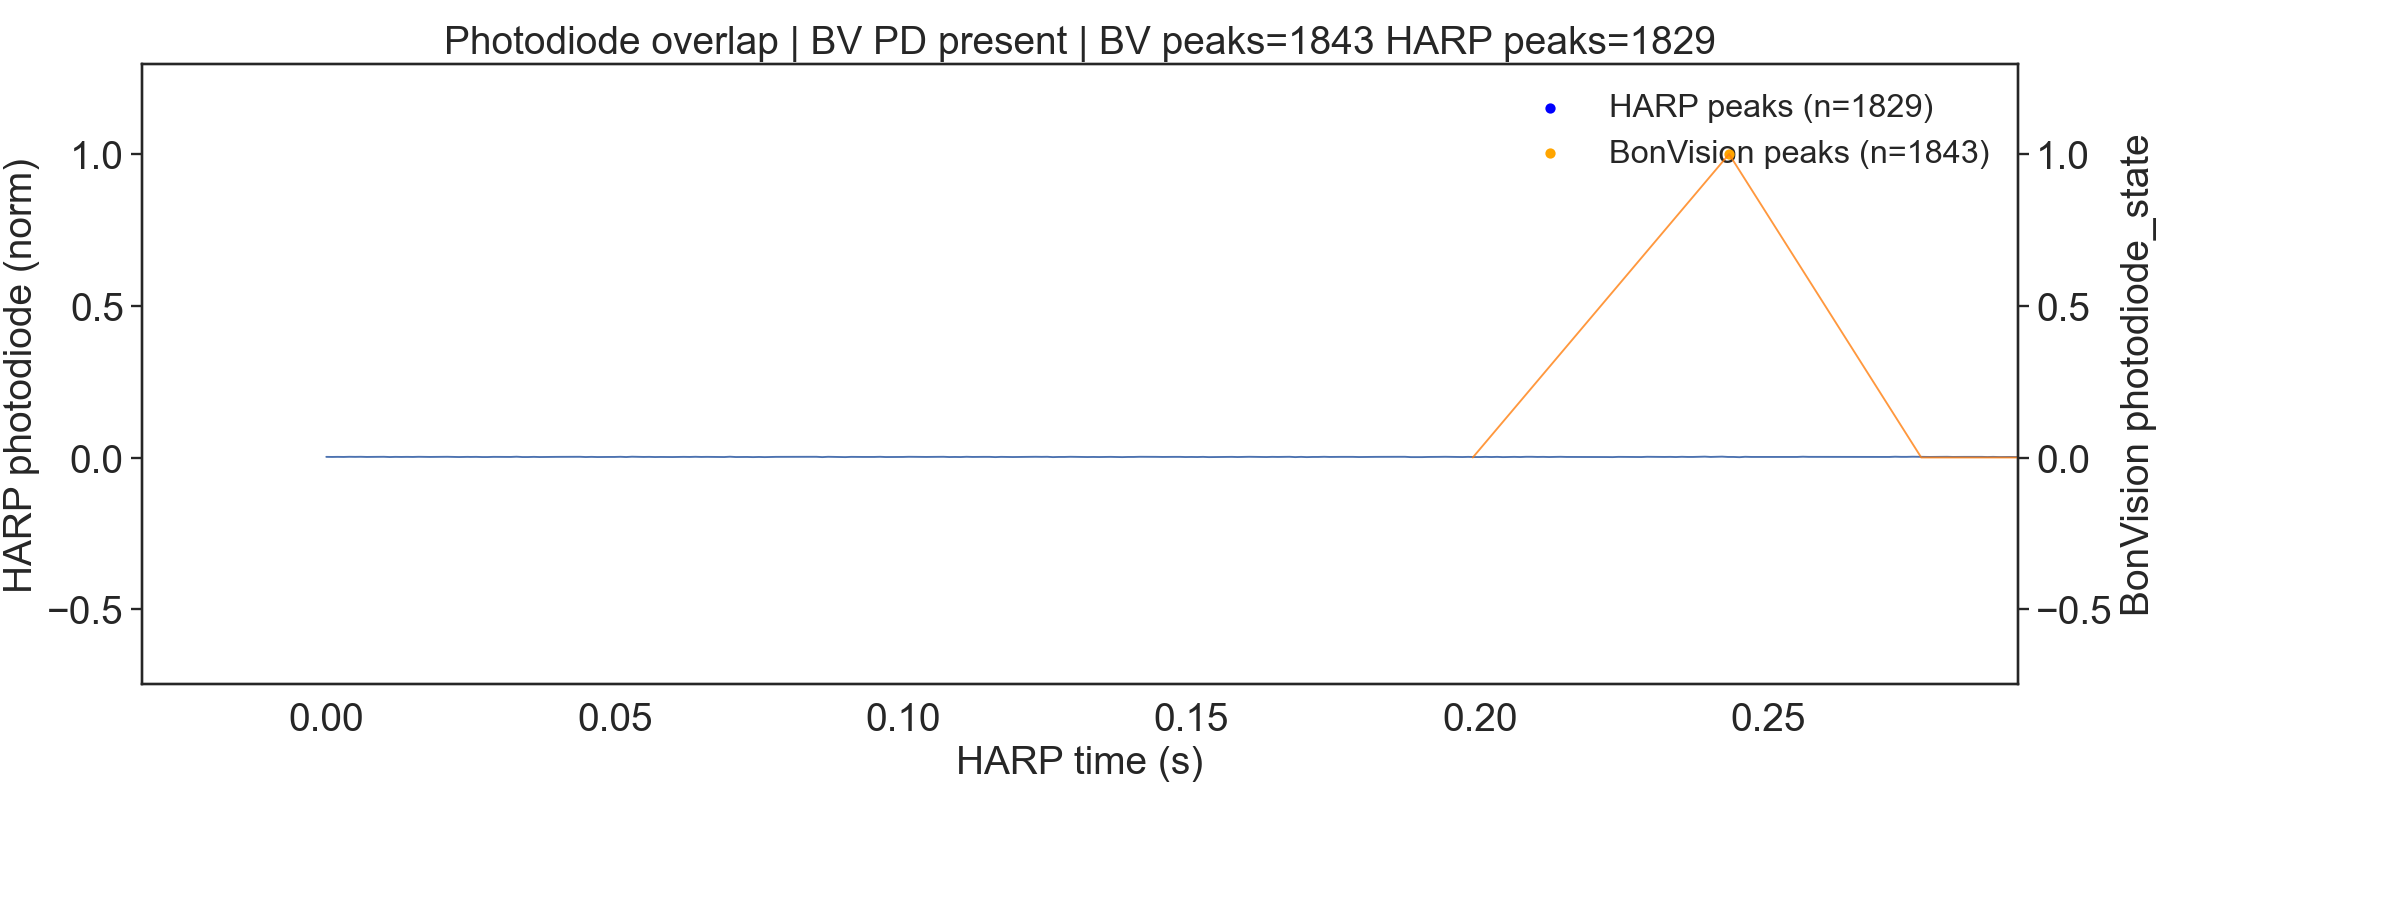


Done.
bad_sessions: ['826033_2026-02-17_13-13-55']
plot_fail_sessions: []


In [11]:
import os, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# update if needed:
# from vip_slap2_analysis.behavior import preprocess as ps

def normalize(x):
    x = np.asarray(x, dtype=float)
    if np.nanmax(x) == np.nanmin(x):
        return x * 0.0
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

bad_sessions = []
plot_fail_sessions = []

for idx, row in process_df.iterrows():
    session_dir = row["session_dir"]
    session_id = row.get("session_id", f"idx{idx}")

    # --- find files
    ev_matches = glob.glob(os.path.join(session_dir, "**", "bonsai_event_log*.csv"), recursive=True)
    if not ev_matches:
        print(f"[SKIP] {session_id}: no bonsai_event_log*.csv under {session_dir}")
        continue
    datapath = Path(ev_matches[0])

    pd_matches = glob.glob(str(datapath.parent / "extracted_files" / "photodiode*.pkl"))
    if not pd_matches:
        print(f"[SKIP] {session_id}: no photodiode*.pkl under {datapath.parent/'extracted_files'}")
        continue
    pd_path = Path(pd_matches[0])

    print(f"\n=== {session_id} ===")
    print(f"event_log: {datapath}")
    print(f"photodiode: {pd_path}")

    # --- load
    stim_df = pd.read_csv(datapath)
    pd_df = pd.read_pickle(pd_path)

    # stimulus ID QC (your original)
    vals = stim_df["Value"].astype(str).values
    num_stim_names = sum(".tif" in v.lower() for v in np.unique(vals))  # catches tif/tiff
    print(f"unique stim IDs (tif/tiff): {num_stim_names}")

    if num_stim_names <= 1:
        print("[BAD] Stimulus IDs not correctly recorded")
        bad_sessions.append(session_id)
        continue

    # --- run correction (IMPORTANT: returns df, meta)
    if 'corrected_timestamps' not in stim_df.keys():
        try:
            corrected_df, meta = ps.correct_event_log(
                datapath,
                pd_path,
                qc_dir=datapath.parents[1],
                savepath=datapath,                 # overwrites file
                use_piecewise_warp=True,
                insert_missing_first_stim_rows=True,  # recommended if already corrected previously
            )
            print(f"[OK] corrected via {meta.alignment_method} | slope={meta.slope:.6f} b={meta.intercept:.3f}s")
        except Exception as e:
            print(f"[FAIL] correction failed: {e}")
            plot_fail_sessions.append(session_id)
            continue
    else:
        corrected_df = stim_df
        print(f'{row["session_id"]} timestamps already corrected')

    # --- build HARP time
    try:
        pd_df = pd_df.copy()
        pd_df["time_s"] = pd_df.index.values.astype(float) - float(pd_df.index.values.astype(float)[0])
        norm_pd = normalize(pd_df["AnalogInput0"].to_numpy(dtype=float))
    except Exception as e:
        print(f"[FAIL] could not prep photodiode trace: {e}")
        plot_fail_sessions.append(session_id)
        continue

    # --- plotting: overlay on common x-axis (HARP time)
    try:
        fig, ax = plt.subplots(figsize=(16, 6))

        # 1) HARP photodiode (normalized)
        ax.plot(pd_df["time_s"], norm_pd, linewidth=1)
        ax.set_xlabel("HARP time (s)")
        ax.set_ylabel("HARP photodiode (norm)")

        harp_peaks = find_peaks(norm_pd, distance=750, height=0.5)[0]
        h_sc = ax.scatter(pd_df["time_s"].iloc[harp_peaks], norm_pd[harp_peaks], s=20,color='blue')

        # 2) BV photodiode if present (use corrected_timestamps which are HARP-aligned)
        # corrected_df always has corrected_timestamps; photodiode_state may be all-NaN
        bv_has_pd = ("photodiode_state" in corrected_df.columns) and corrected_df["photodiode_state"].notna().any()
        b_sc = None

        if bv_has_pd:
            # use only frame rows for a clean BV PD step trace
            frame_mask = corrected_df["Value"].astype(str).str.lower().eq("frame")
            bv_t = corrected_df.loc[frame_mask, "corrected_timestamps"].to_numpy(dtype=float)
            bv_pd = corrected_df.loc[frame_mask, "photodiode_state"].ffill().fillna(0.0).to_numpy(dtype=float)

            ax2 = ax.twinx()
            ax2.plot(bv_t, bv_pd, linewidth=1, alpha=0.8,color='tab:orange')
            ax2.set_ylabel("BonVision photodiode_state")

            bon_peaks = find_peaks(bv_pd, distance=5, height=1)[0]
            b_sc = ax2.scatter(bv_t[bon_peaks], bv_pd[bon_peaks], s=20,color='orange')

            title = f"Photodiode overlap | BV PD present | BV peaks={len(bon_peaks)} HARP peaks={len(harp_peaks)}"
        else:
            title = f"Photodiode overlap | BV PD missing | HARP peaks={len(harp_peaks)}"

        ax.set_title(title)

        # Legend
        handles = [h_sc]
        labels = [f"HARP peaks (n={len(harp_peaks)})"]
        if b_sc is not None:
            handles.append(b_sc)
            labels.append(f"BonVision peaks (n={len(bon_peaks)})")

        ax.legend(handles, labels, frameon=False, loc="upper right")
        fig.tight_layout()
        plt.show()

    except Exception as e:
        print(f"[WARN] plot failed: {e}")
        plot_fail_sessions.append(session_id)
        continue

print("\nDone.")
print("bad_sessions:", bad_sessions)
print("plot_fail_sessions:", plot_fail_sessions)

In [ ]:
from scipy.signal import medfilt
t = test_pd_df.index - test_pd_df.index[0]
y = test_pd_df["AnalogInput0"].values.astype(float)

y_s = medfilt(y, kernel_size=9)
thr = (np.percentile(y_s, 95) + np.percentile(y_s, 5)) / 2.0
binary = (y_s > thr).astype(np.int8)
db = np.diff(binary, prepend=binary[0])

t_rise = t[np.where(db == 1)[0]]
t_fall = t[np.where(db == -1)[0]]

print("thr:", thr)
print("first rise:", t_rise[0] if len(t_rise) else None)
print("first fall:", t_fall[0] if len(t_fall) else None)
print("rise->rise median:", np.median(np.diff(t_rise)))
print("rise->fall median:", np.median(t_fall[:min(len(t_fall),len(t_rise))] - t_rise[:min(len(t_fall),len(t_rise))]))

### Test new alignment method photodiode signal captured in bonsai_event_log.csv

In [ ]:
stim_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\test_subject\test_subject_2026-02-20_13-34-41\behavior\VCO1_Behavior.harp\bonsai_event_log.csv"
pd_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\test_subject\test_subject_2026-02-20_13-34-41\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl"

In [ ]:
stim_df = pd.read_csv(stim_path)
pd_df = pd.read_pickle(pd_path)
pd_df['time'] = pd_df.index - pd_df.index[0]

In [ ]:
stim_df

In [ ]:
val = stim_df['Value'].astype(str)

pd_event = np.full(len(stim_df), np.nan, dtype=float)
pd_event[val.str.fullmatch(r"Photodiode-1", case=False)] = 1.0
pd_event[val.str.fullmatch(r"Photodiode-0", case=False)] = 0.0

stim_df["photodiode_event"] = pd_event
stim_df["photodiode_state"] = pd.Series(pd_event).ffill().to_numpy()

In [ ]:
stim_df

In [ ]:
# stimulus_df = ps.align_event_log_to_harp(stim_df,pd_df,qc_dir=Path(stim_path).parents[1],savepath = stim_path)

In [ ]:
fig,ax=plt.subplots(2,figsize=(16,10),sharex=True)

for axis in ax.flatten():
    axis.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
    axis.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

bon_peaks = find_peaks(stim_df['photodiode_state'],distance = 5,height=1)[0]
ax[0].plot(stim_df['Timestamp'],stim_df['photodiode_state'])
ax[0].set_ylabel('Photodiode value')
ax[0].set_xlabel('BonVision time (s)')
a = ax[0].scatter(stim_df['Timestamp'][peaks],stim_df['photodiode_state'][peaks],color='r')
ax[0].set_title('BonVision photodiode signal',fontsize=25)
ax[0].legend(handles=[a],labels=[f'Photodiode pulse, n = {len(bon_peaks)}'],frameon=False,fontsize=12)

harp_peaks = find_peaks(pd_df['AnalogInput0'],distance = 600,height=100)[0]
ax[1].plot(pd_df['time'],pd_df['AnalogInput0'])
ax[1].set_ylabel('Photodiode value')
ax[1].set_xlabel('HARP time (s)')
ax[1].scatter(pd_df['time'].iloc[harp_peaks],pd_df['AnalogInput0'].iloc[harp_peaks],color='r')
ax[1].set_title('HARP photodiode signal',fontsize=25)
ax[1].legend(handles=[a],labels=[f'Photodiode pulse, n = {len(harp_peaks)}'],frameon=False,fontsize=12)

fig.tight_layout()

In [ ]:
data_dir = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\temp"

In [ ]:
harp_paths = glob.glob(os.path.join(data_dir,'**','**.harp'),recursive=True)

In [ ]:
for path in harp_paths:
    ps.process_single_harp_session(path)

In [ ]:
Path(stim_path).parents[2].stem

In [ ]:
for i,path in enumerate(harp_paths):
    stim_path = glob.glob(os.path.join(path,'*.csv'))[0]
    pd_path = glob.glob(os.path.join(path,'**','photodiode.pkl'))[0]
    
    stim_df = pd.read_csv(stim_path)
    pd_df = pd.read_pickle(pd_path)
    
    pd_df['time'] = pd_df.index - pd_df.index[0]
    
    val = stim_df['Value'].astype(str)
    pd_event = np.full(len(stim_df), np.nan, dtype=float)
    pd_event[val.str.fullmatch(r"Photodiode-1", case=False)] = 1.0
    pd_event[val.str.fullmatch(r"Photodiode-0", case=False)] = 0.0

    stim_df["photodiode_event"] = pd_event
    stim_df["photodiode_state"] = pd.Series(pd_event).ffill().to_numpy()

    fig,ax=plt.subplots(2,figsize=(16,10),sharex=True)

    for axis in ax.flatten():
        axis.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
        axis.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

    bon_peaks = find_peaks(stim_df['photodiode_state'],distance = 5,height=1)[0]
    ax[0].plot(stim_df['Timestamp']+.110,stim_df['photodiode_state'])
    ax[0].set_ylabel('Photodiode value')
    ax[0].set_xlabel('BonVision time (s)')
    a = ax[0].scatter(stim_df['Timestamp'][bon_peaks],stim_df['photodiode_state'][bon_peaks],color='r')
    ax[0].set_title('BonVision photodiode signal',fontsize=25)
    ax[0].legend(handles=[a],labels=[f'Photodiode pulse, n = {len(bon_peaks)}'],frameon=False,fontsize=12)

    harp_peaks = find_peaks(pd_df['AnalogInput0'],distance = 700,height=100)[0]
    ax[1].plot(pd_df['time'],pd_df['AnalogInput0'])
    ax[1].set_ylabel('Photodiode value')
    ax[1].set_xlabel('HARP time (s)')
    ax[1].scatter(pd_df['time'].iloc[harp_peaks],pd_df['AnalogInput0'].iloc[harp_peaks],color='r')
    ax[1].set_title('HARP photodiode signal',fontsize=25)
    ax[1].legend(handles=[a],labels=[f'Photodiode pulse, n = {len(harp_peaks)}'],frameon=False,fontsize=12)

    fig.tight_layout()

    stimulus_df = ps.align_event_log_to_harp(stim_df,pd_df,savepath = stim_path)
    print(f'Corrected time offsets for {Path(stim_path).parents[2].stem}')

In [ ]:
for i,path in enumerate(harp_paths):
    stim_path = glob.glob(os.path.join(path,'*.csv'))[0]
    pd_path = glob.glob(os.path.join(path,'**','photodiode.pkl'))[0]
    
    stim_df = pd.read_csv(stim_path)
    pd_df = pd.read_pickle(pd_path)
    
    pd_df['time'] = pd_df.index - pd_df.index[0]
    
    stimulus_df,_ = ps.align_event_log_to_harp(stim_df,pd_df,savepath = stim_path)
    print(f'Corrected time offsets for {Path(stim_path).parents[2].stem} \nat{stim_path}')

    fig,ax=plt.subplots(figsize=(16,10),sharex=True)

    norm_pd = normalize(pd_df['AnalogInput0'])
    
    ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
    ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

    bon_peaks = find_peaks(stimulus_df['photodiode_state'],distance = 5,height=1)[0]
    ax.plot(stimulus_df['corrected_timestamp_harp'],stimulus_df['photodiode_state'])
    ax.set_ylabel('Photodiode value')
    ax.set_xlabel('BonVision time (s)')
    a = ax.scatter(stimulus_df['corrected_timestamp_harp'][bon_peaks],stimulus_df['photodiode_state'][bon_peaks],color='r')

    harp_peaks = find_peaks(norm_pd,distance = 700,height=0.5)[0]
    ax.plot(pd_df['time'],norm_pd)
    ax.set_ylabel('Photodiode value')
    ax.set_xlabel('HARP time (s)')
    b = ax.scatter(pd_df['time'].iloc[harp_peaks],norm_pd.values[harp_peaks],color='g')
    
    ax.set_title('Photodiode overlap',fontsize=25)
    
    ax.legend(handles=[a,b],labels=[f'BonVision pulses, n = {len(bon_peaks)}',f'HARP pulse, n = {len(harp_peaks)}'],frameon=False,fontsize=12)

    fig.tight_layout()

In [ ]:
fig,ax=plt.subplots()

ax.plot(pd_df['time'],pd_df['AnalogInput0'])

In [ ]:
pd_df['time'] = pd_df.index - pd_df.index[0]

In [ ]:
pd_df = pd.read_pickle(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-18_11-57-04\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl")

In [ ]:
norm_pd.values

In [ ]:
data_dir = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\tmp"

In [ ]:
stim_paths = glob.glob(os.path.join(data_dir,'**.csv'))
pd_paths = glob.glob(os.path.join(data_dir,'**.pkl'))

In [ ]:
for i,(s_path,p_path) in enumerate(zip(stim_paths,pd_paths)):
    stim_df,meta = ps.correct_event_log(s_path,p_path,savepath=s_path,use_piecewise_warp=True)
    
    if i>=1:
        print(meta)
        pd_df = pd.read_pickle(p_path)
        pd_df['time'] = pd_df.index - pd_df.index[0]
        
        fig,ax=plt.subplots(2,figsize=(16,10),sharex=True)

        for axis in ax.flatten():
            axis.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
            axis.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

        bon_peaks = find_peaks(stim_df['photodiode_state'],distance = 5,height=1)[0]
        ax[0].plot(stim_df['corrected_timestamps'],stim_df['photodiode_state'])
        ax[0].set_ylabel('Photodiode value')
        ax[0].set_xlabel('BonVision time (s)')
        a = ax[0].scatter(stim_df['corrected_timestamps'][bon_peaks],stim_df['photodiode_state'][bon_peaks],color='r')
        ax[0].set_title('BonVision photodiode signal',fontsize=25)
        ax[0].legend(handles=[a],labels=[f'Photodiode pulse, n = {len(bon_peaks)}'],frameon=False,fontsize=12)

        harp_peaks = find_peaks(pd_df['AnalogInput0'],distance = 600,height=100)[0]
        ax[1].plot(pd_df['time'],pd_df['AnalogInput0'])
        ax[1].set_ylabel('Photodiode value')
        ax[1].set_xlabel('HARP time (s)')
        b = ax[1].scatter(pd_df['time'].iloc[harp_peaks],pd_df['AnalogInput0'].iloc[harp_peaks],color='r')
        ax[1].set_title('HARP photodiode signal',fontsize=25)
        ax[1].legend(handles=[b],labels=[f'Photodiode pulse, n = {len(harp_peaks)}'],frameon=False,fontsize=12)

        fig.tight_layout()

In [ ]:
fig,ax=plt.subplots(figsize=(16,8),sharex=True)

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

bon_peaks = find_peaks(stim_df['photodiode_state'],distance = 5,height=1)[0]
ax.plot(stim_df['corrected_timestamps'],stim_df['photodiode_state'],label='BonVision photodiode')
ax.set_ylabel('Photodiode value')
ax.set_xlabel('BonVision time (s)')
# a = ax.scatter(stim_df['corrected_timestamps'][bon_peaks],stim_df['photodiode_state'][bon_peaks],color='r')

harp_peaks = find_peaks(pd_df['AnalogInput0'],distance = 700,height=1000)[0]
ax.plot(pd_df['time'],normalize(pd_df['AnalogInput0']),label='HARP photodiode')
ax.set_ylabel('Photodiode value')
ax.set_xlabel('HARP time (s)')
# b = ax.scatter(pd_df['time'].iloc[harp_peaks],normalize(pd_df['AnalogInput0']).values[harp_peaks],color='g')

ax.set_title('Photodiode alignment',fontsize=25)

ax.legend(handles=[a,b],labels=[f'BonVision pulse, n = {len(bon_peaks)}',f'HARP pulse, n = {len(harp_peaks)}'],frameon=False,fontsize=12)

fig.tight_layout()

### Check image presentation times against harp photodiode

In [ ]:
stim_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\tmp\bonsai_event_log1.csv"
pd_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\tmp\photodiode1.pkl"

In [ ]:
stim_df = pd.read_csv(stim_path)

pd_df = pd.read_pickle(pd_path)
pd_df['time'] = pd_df.index - pd_df.index[0]

In [ ]:
fig,ax=plt.subplots(figsize=(8,4))

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

ax.plot(pd_df['time'],normalize(pd_df['AnalogInput0']),label='HARP')
ax.plot(stim_df['corrected_timestamps'],stim_df['photodiode_state'],label='BonVision')

ax.set_ylabel('Photodiode state')
ax.set_xlabel('HARP time (s)')

ax.set_xlim(11.5,16)

ax.legend(fontsize=12,frameon=False)

ax.set_title('HARP/BonVision time alignment')

fig.tight_layout()

In [ ]:
stim_df